<a href="https://colab.research.google.com/github/Abdulrahman1806/YOLO-Helmet-Detection/blob/main/YOLO_Helmet_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!kaggle datasets download -d andrewmvd/hard-hat-detection

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection
License(s): CC0-1.0
100% 1.22G/1.22G [00:11<00:00, 116MB/s]



In [ ]:
!unzip -q "/content/hard-hat-detection.zip" -d "/content/dataset"

In [ ]:
import os

print(os.listdir("/content/dataset"))

['images', 'annotations']


In [ ]:
images = os.listdir("/content/dataset/images")
annotations = os.listdir("/content/dataset/annotations")

print("Number of images:", len(images))
print("Number of annotations:", len(annotations))

Number of images: 5000
Number of annotations: 5000


In [ ]:
print(images[:5])
print(annotations[:5])

['hard_hat_workers4928.png', 'hard_hat_workers1964.png', 'hard_hat_workers2604.png', 'hard_hat_workers4373.png', 'hard_hat_workers3601.png']
['hard_hat_workers4493.xml', 'hard_hat_workers3668.xml', 'hard_hat_workers4934.xml', 'hard_hat_workers2606.xml', 'hard_hat_workers4706.xml']


In [ ]:
annotation_path = "/content/dataset/annotations/hard_hat_workers3584.xml"

with open(annotation_path, "r") as file:
    print(file.read())


<annotation>
    <folder>images</folder>
    <filename>hard_hat_workers3584.png</filename>
    <size>
        <width>416</width>
        <height>415</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>136</xmin>
            <ymin>70</ymin>
            <xmax>228</xmax>
            <ymax>150</ymax>
        </bndbox>
    </object>
    <object>
        <name>helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>208</xmin>
            <ymin>106</ymin>
            <xmax>279</xmax>
            <ymax>191</ymax>
        </bndbox>
    </object>
    <object>
        <name>helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</truncate

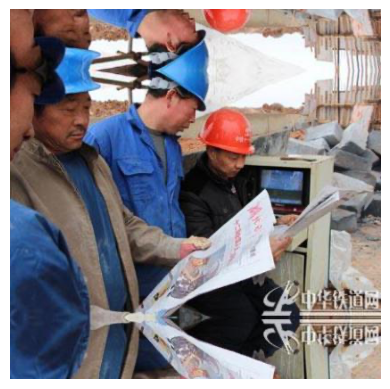

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

image_path = "/content/dataset/images/hard_hat_workers3584.png"

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

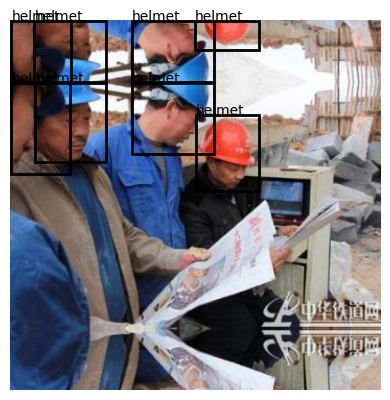

In [ ]:
#Instead of manually entering the coordinates for the 8 helmets, we’ll have Python read the XML file itself and draw the boxes.
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

image_path = "/content/dataset/images/hard_hat_workers3584.png"
xml_path = "/content/dataset/annotations/hard_hat_workers3584.xml"

img = Image.open(image_path)

tree = ET.parse(xml_path)
root = tree.getroot()

fig, ax = plt.subplots()

ax.imshow(img)

for obj in root.findall("object"):

    class_name = obj.find("name").text

    box = obj.find("bndbox")

    xmin = int(box.find("xmin").text)
    ymin = int(box.find("ymin").text)
    xmax = int(box.find("xmax").text)
    ymax = int(box.find("ymax").text)

    width = xmax - xmin
    height = ymax - ymin

    rectangle = patches.Rectangle(
        (xmin, ymin),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)
    ax.text(xmin, ymin, class_name)

plt.axis("off")
plt.show()

In [ ]:
# Find all object classes in the Pascal VOC annotations

import glob
import xml.etree.ElementTree as ET

classes = set()

for xml_file in glob.glob("/content/dataset/annotations/*.xml"):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        classes.add(obj.find("name").text)

print("Classes:", classes)

Classes: {'head', 'person', 'helmet'}


In [ ]:
# Define YOLO class IDs for helmet, head, and person

class_map = {
    "helmet": 0,
    "head": 1,
    "person": 2
}

print(class_map)

{'helmet': 0, 'head': 1, 'person': 2}


In [ ]:
# Convert one Pascal VOC bounding box to YOLO format

img_width = 416
img_height = 415

xmin = 136
ymin = 70
xmax = 228
ymax = 150

x_center = ((xmin + xmax) / 2) / img_width
y_center = ((ymin + ymax) / 2) / img_height

box_width = (xmax - xmin) / img_width
box_height = (ymax - ymin) / img_height

print("x_center:", x_center)
print("y_center:", y_center)
print("width:", box_width)
print("height:", box_height)

x_center: 0.4375
y_center: 0.26506024096385544
width: 0.22115384615384615
height: 0.1927710843373494


In [ ]:
# Create a function to convert Pascal VOC boxes to YOLO format

def voc_to_yolo(xmin, ymin, xmax, ymax, img_width, img_height):
    x_center = ((xmin + xmax) / 2) / img_width
    y_center = ((ymin + ymax) / 2) / img_height
    box_width = (xmax - xmin) / img_width
    box_height = (ymax - ymin) / img_height

    return x_center, y_center, box_width, box_height

In [ ]:
# Test the VOC-to-YOLO conversion function on one bounding box

result = voc_to_yolo(
    136, 70, 228, 150,
    416, 415
)

print(result)

(0.4375, 0.26506024096385544, 0.22115384615384615, 0.1927710843373494)


In [ ]:
# Convert one full Pascal VOC XML annotation to YOLO label lines

xml_path = "/content/dataset/annotations/hard_hat_workers3584.xml"

tree = ET.parse(xml_path)
root = tree.getroot()

img_width = int(root.find("size/width").text)
img_height = int(root.find("size/height").text)

for obj in root.findall("object"):
    class_name = obj.find("name").text
    class_id = class_map[class_name]

    box = obj.find("bndbox")

    xmin = int(box.find("xmin").text)
    ymin = int(box.find("ymin").text)
    xmax = int(box.find("xmax").text)
    ymax = int(box.find("ymax").text)

    x_center, y_center, box_width, box_height = voc_to_yolo(
        xmin, ymin, xmax, ymax,
        img_width, img_height
    )

    print(class_id, x_center, y_center, box_width, box_height)

0 0.4375 0.26506024096385544 0.22115384615384615 0.1927710843373494
0 0.5853365384615384 0.3578313253012048 0.17067307692307693 0.20481927710843373
0 0.1622596153846154 0.27590361445783135 0.18990384615384615 0.21445783132530122
0 0.08173076923076923 0.29156626506024097 0.15865384615384615 0.2457831325301205
0 0.4387019230769231 0.08313253012048193 0.22355769230769232 0.16626506024096385
0 0.5841346153846154 0.03975903614457831 0.17307692307692307 0.07951807228915662
0 0.16105769230769232 0.08313253012048193 0.19230769230769232 0.16626506024096385
0 0.0829326923076923 0.08313253012048193 0.16105769230769232 0.16626506024096385


In [ ]:
# Save one Pascal VOC annotation as a YOLO .txt label file

output_path = "/content/hard_hat_workers3584.txt"

with open(output_path, "w") as f:
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        class_id = class_map[class_name]

        box = obj.find("bndbox")

        xmin = int(box.find("xmin").text)
        ymin = int(box.find("ymin").text)
        xmax = int(box.find("xmax").text)
        ymax = int(box.find("ymax").text)

        x_center, y_center, box_width, box_height = voc_to_yolo(
            xmin, ymin, xmax, ymax,
            img_width, img_height
        )

        f.write(
            f"{class_id} {x_center} {y_center} {box_width} {box_height}\n"
        )

print("Saved to:", output_path)

Saved to: /content/hard_hat_workers3584.txt


In [ ]:
# Check the saved YOLO label file

with open("/content/hard_hat_workers3584.txt", "r") as f:
    print(f.read())

0 0.4375 0.26506024096385544 0.22115384615384615 0.1927710843373494
0 0.5853365384615384 0.3578313253012048 0.17067307692307693 0.20481927710843373
0 0.1622596153846154 0.27590361445783135 0.18990384615384615 0.21445783132530122
0 0.08173076923076923 0.29156626506024097 0.15865384615384615 0.2457831325301205
0 0.4387019230769231 0.08313253012048193 0.22355769230769232 0.16626506024096385
0 0.5841346153846154 0.03975903614457831 0.17307692307692307 0.07951807228915662
0 0.16105769230769232 0.08313253012048193 0.19230769230769232 0.16626506024096385
0 0.0829326923076923 0.08313253012048193 0.16105769230769232 0.16626506024096385



In [ ]:
# Convert all Pascal VOC XML annotations to YOLO .txt label files

import os
import glob
import xml.etree.ElementTree as ET

labels_dir = "/content/dataset/labels"
os.makedirs(labels_dir, exist_ok=True)

for xml_path in glob.glob("/content/dataset/annotations/*.xml"):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img_width = int(root.find("size/width").text)
    img_height = int(root.find("size/height").text)

    filename = os.path.splitext(os.path.basename(xml_path))[0]
    output_path = os.path.join(labels_dir, filename + ".txt")

    with open(output_path, "w") as f:
        for obj in root.findall("object"):
            class_name = obj.find("name").text
            class_id = class_map[class_name]

            box = obj.find("bndbox")

            xmin = int(box.find("xmin").text)
            ymin = int(box.find("ymin").text)
            xmax = int(box.find("xmax").text)
            ymax = int(box.find("ymax").text)

            x_center, y_center, box_width, box_height = voc_to_yolo(
                xmin, ymin, xmax, ymax,
                img_width, img_height
            )

            f.write(
                f"{class_id} {x_center} {y_center} {box_width} {box_height}\n"
            )

print("Conversion completed.")

Conversion completed.


In [ ]:
# Check that all XML annotations were converted to YOLO label files

yolo_labels = os.listdir("/content/dataset/labels")

print("Number of YOLO labels:", len(yolo_labels))

Number of YOLO labels: 5000


In [ ]:
# Split the dataset into train, validation, and test sets

from sklearn.model_selection import train_test_split

all_images = os.listdir("/content/dataset/images")

train_images, temp_images = train_test_split(
    all_images,
    test_size=0.30,
    random_state=42
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=1/3,
    random_state=42
)

print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))

Train: 3500
Validation: 1000
Test: 500


In [ ]:
# Create folders for train, validation, and test images and labels

import os

folders = [
    "/content/yolo_dataset/images/train",
    "/content/yolo_dataset/images/val",
    "/content/yolo_dataset/images/test",
    "/content/yolo_dataset/labels/train",
    "/content/yolo_dataset/labels/val",
    "/content/yolo_dataset/labels/test"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created.")

Folders created.


In [ ]:
# Copy the training images and their YOLO labels into the train folders

import shutil

for image_name in train_images:
    image_source = os.path.join("/content/dataset/images", image_name)
    image_destination = os.path.join("/content/yolo_dataset/images/train", image_name)

    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_source = os.path.join("/content/dataset/labels", label_name)
    label_destination = os.path.join("/content/yolo_dataset/labels/train", label_name)

    shutil.copy(image_source, image_destination)
    shutil.copy(label_source, label_destination)

print("Training files copied.")

Training files copied.


In [ ]:
# Check that all training images and labels were copied correctly

train_image_count = len(os.listdir("/content/yolo_dataset/images/train"))
train_label_count = len(os.listdir("/content/yolo_dataset/labels/train"))

print("Train images:", train_image_count)
print("Train labels:", train_label_count)

Train images: 3500
Train labels: 3500


In [ ]:
# Copy the validation images and their YOLO labels into the validation folders

for image_name in val_images:
    image_source = os.path.join("/content/dataset/images", image_name)
    image_destination = os.path.join("/content/yolo_dataset/images/val", image_name)

    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_source = os.path.join("/content/dataset/labels", label_name)
    label_destination = os.path.join("/content/yolo_dataset/labels/val", label_name)

    shutil.copy(image_source, image_destination)
    shutil.copy(label_source, label_destination)

print("Validation files copied.")

Validation files copied.


In [ ]:
# Check that all validation images and labels were copied correctly

val_image_count = len(os.listdir("/content/yolo_dataset/images/val"))
val_label_count = len(os.listdir("/content/yolo_dataset/labels/val"))

print("Validation images:", val_image_count)
print("Validation labels:", val_label_count)

Validation images: 1000
Validation labels: 1000


In [ ]:
# Copy the test images and their YOLO labels into the test folders

for image_name in test_images:
    image_source = os.path.join("/content/dataset/images", image_name)
    image_destination = os.path.join("/content/yolo_dataset/images/test", image_name)

    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_source = os.path.join("/content/dataset/labels", label_name)
    label_destination = os.path.join("/content/yolo_dataset/labels/test", label_name)

    shutil.copy(image_source, image_destination)
    shutil.copy(label_source, label_destination)

print("Test files copied.")

Test files copied.


In [ ]:
# Check that all test images and labels were copied correctly

test_image_count = len(os.listdir("/content/yolo_dataset/images/test"))
test_label_count = len(os.listdir("/content/yolo_dataset/labels/test"))

print("Test images:", test_image_count)
print("Test labels:", test_label_count)

Test images: 500
Test labels: 500


In [ ]:
# Install the Ultralytics YOLO package

!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.0 MB/s eta 0:00:00


In [ ]:
# Verify that Ultralytics YOLO was installed successfully

import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.147


In [ ]:
# Create the data.yaml file that tells YOLO where the dataset is and what classes it contains

yaml_content = """
path: /content/yolo_dataset

train: images/train
val: images/val
test: images/test

names:
  0: helmet
  1: head
  2: person
"""

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created.")

data.yaml created.


In [ ]:
# Check the data.yaml file before training YOLO

with open("/content/yolo_dataset/data.yaml", "r") as f:
    print(f.read())


path: /content/yolo_dataset

train: images/train
val: images/val
test: images/test

names:
  0: helmet
  1: head
  2: person



In [ ]:
# Load a pretrained YOLO model to use as the starting point for training

from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("Model loaded.")

Model loaded.


In [ ]:
# Check whether Google Colab has a GPU available for YOLO training

import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
# Train YOLO on the helmet, head, and person dataset

results = model.train(
    data="/content/yolo_dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.147 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimiz

In [ ]:
# Count how many helmet, head, and person annotations exist in the training set

class_counts = {
    0: 0,  # helmet
    1: 0,  # head
    2: 0   # person
}

train_labels_dir = "/content/yolo_dataset/labels/train"

for label_file in os.listdir(train_labels_dir):
    label_path = os.path.join(train_labels_dir, label_file)

    with open(label_path, "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

print("Helmet:", class_counts[0])
print("Head:", class_counts[1])
print("Person:", class_counts[2])

Helmet: 13305
Head: 4047
Person: 498


In [ ]:
# Count how many helmet, head, and person annotations exist in the full dataset

full_class_counts = {
    0: 0,
    1: 0,
    2: 0
}

labels_dir = "/content/dataset/labels"

for label_file in os.listdir(labels_dir):
    label_path = os.path.join(labels_dir, label_file)

    with open(label_path, "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            full_class_counts[class_id] += 1

print("Helmet:", full_class_counts[0])
print("Head:", full_class_counts[1])
print("Person:", full_class_counts[2])

Helmet: 18966
Head: 5785
Person: 751


In [ ]:
# Count how many images contain at least one person annotation

person_image_count = 0

for label_file in os.listdir("/content/dataset/labels"):
    label_path = os.path.join("/content/dataset/labels", label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    has_person = any(int(line.split()[0]) == 2 for line in lines)

    if has_person:
        person_image_count += 1

print("Images containing person:", person_image_count)

Images containing person: 158


In [ ]:
# Count how many images containing person are in train, validation, and test sets

def count_person_images(labels_folder):
    count = 0

    for label_file in os.listdir(labels_folder):
        label_path = os.path.join(labels_folder, label_file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        if any(int(line.split()[0]) == 2 for line in lines):
            count += 1

    return count


print("Train person images:", count_person_images("/content/yolo_dataset/labels/train"))
print("Validation person images:", count_person_images("/content/yolo_dataset/labels/val"))
print("Test person images:", count_person_images("/content/yolo_dataset/labels/test"))

Train person images: 111
Validation person images: 32
Test person images: 15


In [ ]:
# Find the first training image that contains a person annotation

for label_file in os.listdir("/content/yolo_dataset/labels/train"):
    label_path = os.path.join("/content/yolo_dataset/labels/train", label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    if any(int(line.split()[0]) == 2 for line in lines):
        print("Person label:", label_file)
        break

Person label: hard_hat_workers1244.txt


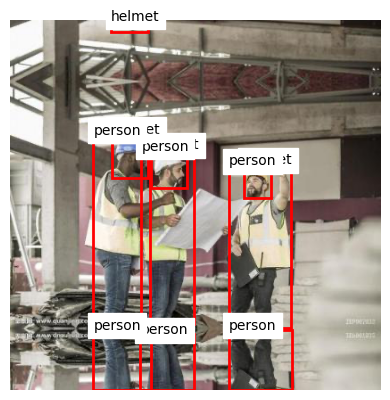

In [ ]:
# Display a training image containing a person and draw all YOLO bounding boxes on it

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image_path = "/content/yolo_dataset/images/train/hard_hat_workers1244.png"
label_path = "/content/yolo_dataset/labels/train/hard_hat_workers1244.txt"

image = Image.open(image_path)
img_width, img_height = image.size

class_names = {
    0: "helmet",
    1: "head",
    2: "person"
}

fig, ax = plt.subplots()
ax.imshow(image)

with open(label_path, "r") as f:
    for line in f:
        class_id, x_center, y_center, box_width, box_height = map(float, line.split())

        class_id = int(class_id)

        box_width *= img_width
        box_height *= img_height
        x_center *= img_width
        y_center *= img_height

        xmin = x_center - box_width / 2
        ymin = y_center - box_height / 2

        rect = patches.Rectangle(
            (xmin, ymin),
            box_width,
            box_height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)
        ax.text(
            xmin,
            ymin,
            class_names[class_id],
            fontsize=10,
            backgroundcolor="white"
        )

plt.axis("off")
plt.show()

In [ ]:
# Display random training images that contain person annotations

import random

person_files = []

for label_file in os.listdir("/content/yolo_dataset/labels/train"):
    label_path = os.path.join("/content/yolo_dataset/labels/train", label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    if any(int(line.split()[0]) == 2 for line in lines):
        person_files.append(label_file)

print(random.sample(person_files, 5))

['hard_hat_workers1011.txt', 'hard_hat_workers873.txt', 'hard_hat_workers4759.txt', 'hard_hat_workers2159.txt', 'hard_hat_workers2361.txt']


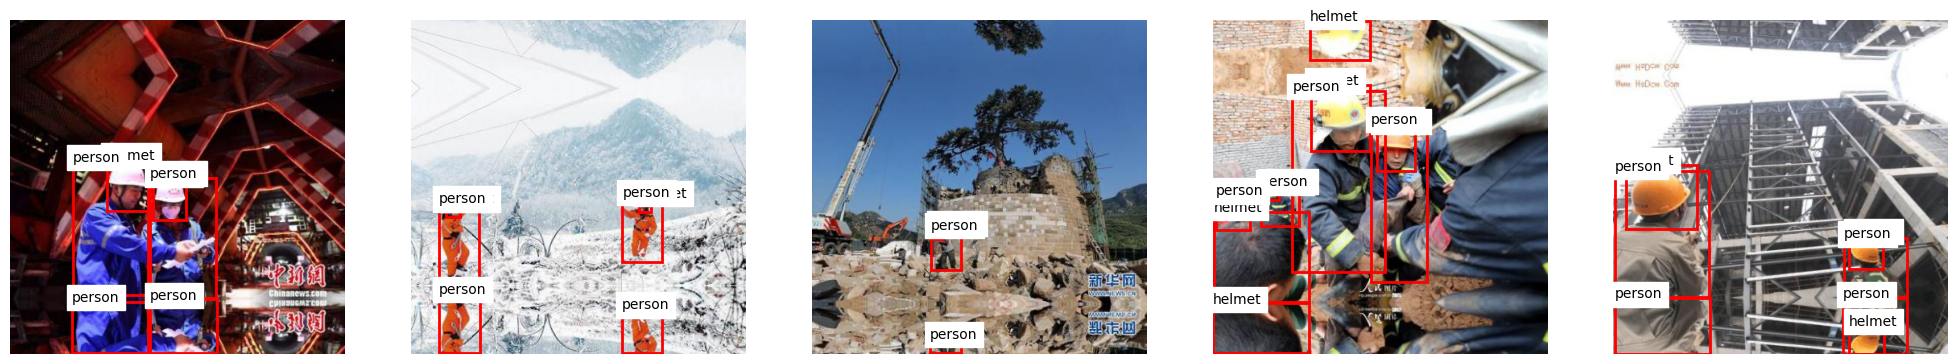

In [ ]:
# Display five person images with their YOLO bounding boxes

selected_files = [
    "hard_hat_workers1011.txt",
    "hard_hat_workers873.txt",
    "hard_hat_workers4759.txt",
    "hard_hat_workers2159.txt",
    "hard_hat_workers2361.txt"
]

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for ax, label_file in zip(axes, selected_files):

    image_file = label_file.replace(".txt", ".png")
    image_path = os.path.join("/content/yolo_dataset/images/train", image_file)
    label_path = os.path.join("/content/yolo_dataset/labels/train", label_file)

    image = Image.open(image_path)
    img_width, img_height = image.size
    ax.imshow(image)

    with open(label_path, "r") as f:
        for line in f:
            class_id, x_center, y_center, box_width, box_height = map(float, line.split())
            class_id = int(class_id)

            x_center *= img_width
            y_center *= img_height
            box_width *= img_width
            box_height *= img_height

            xmin = x_center - box_width / 2
            ymin = y_center - box_height / 2

            rect = patches.Rectangle(
                (xmin, ymin),
                box_width,
                box_height,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)
            ax.text(xmin, ymin, class_names[class_id], backgroundcolor="white")

    ax.axis("off")

plt.show()

In [ ]:
# Calculate the relative sizes of all person bounding boxes in the training set

person_box_areas = []

for label_file in os.listdir("/content/yolo_dataset/labels/train"):
    label_path = os.path.join("/content/yolo_dataset/labels/train", label_file)

    with open(label_path, "r") as f:
        for line in f:
            class_id, x, y, width, height = map(float, line.split())

            if int(class_id) == 2:
                person_box_areas.append(width * height)

print("Number of person boxes:", len(person_box_areas))
print("Smallest:", min(person_box_areas))
print("Average:", sum(person_box_areas) / len(person_box_areas))
print("Largest:", max(person_box_areas))